# MalthusJAX vs Evosax: Uniform Crossover Comparison 🔬

This notebook compares **MalthusJAX's Uniform Crossover** implementation with **Evosax's** native uniform crossover operator.

## Comparison Objectives 🎯

1. **API Differences**: Compare the interfaces and usage patterns
2. **Performance**: Benchmark execution speed and memory usage
3. **Behavioral Equivalence**: Verify both operators produce statistically identical results
4. **Integration**: Show how Evosax operators can be wrapped in MalthusJAX's 3-tier paradigm
5. **Design Philosophy**: Contrast architectural approaches

In [11]:
# Essential imports for comparison
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

# Direct Evosax import
from evosax.algorithms.population_based.simple_ga import crossover as evosax_uniform_crossover

# MalthusJAX components
from malthusjax.core.genome.real_genome import RealGenome, RealGenomeConfig, RealPopulation
from malthusjax.operators.crossover.evosax_crossover import EvosaxUniformCrossoverWrapper
from malthusjax.operators.crossover.real import UniformCrossover as MalthusUniformCrossover

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

# Reproducible random seed
key = jr.PRNGKey(42)

JAX version: 0.8.0
JAX backend: cpu
Available devices: [CpuDevice(id=0)]


## Part 1: Setup and Basic Usage

Let's create test genomes and demonstrate the basic usage of both crossover implementations.

In [12]:
# Create test configuration and parents
config = RealGenomeConfig(
    shape=(10,),
    bounds=(-10.0, 10.0),
    dtype=jnp.float32
)

# Create distinctly different parents for clear visualization
key, k1, k2 = jr.split(key, 3)

parent1 = RealGenome.random_init(k1, config.replace(bounds=(-10.0, -2.0)))
parent2 = RealGenome.random_init(k2, config.replace(bounds=(2.0, 10.0)))

print("Test Parents:")
print(f"Parent 1: {parent1.values}")
print(f"Parent 2: {parent2.values}")
print(f"Euclidean distance: {jnp.linalg.norm(parent1.values - parent2.values):.3f}")

Test Parents:
Parent 1: [-4.178686  -3.6970596 -8.546446  -7.898958  -9.114165  -8.378954
 -7.4584923 -9.155437  -6.561283  -6.1568813]
Parent 2: [7.337925  7.7718935 3.0143576 4.834215  5.3687325 2.3365917 2.2671938
 4.5772324 5.898031  2.3020163]
Euclidean distance: 37.343


## Part 2: API Comparison

Let's compare how each framework handles uniform crossover operations.

In [13]:
# MalthusJAX Uniform Crossover (3-Tier Paradigm)
malthusjax_op = MalthusUniformCrossover(
    num_offspring=1,
    crossover_rate=0.7
)

print("MalthusJAX API:")
print("=" * 50)
print(f"Operator: {type(malthusjax_op).__name__}")
print(f"Keys per operation: {malthusjax_op.num_keys_per_atomic_operation}")
print(f"Num offspring: {malthusjax_op.num_offspring}")
print(f"Crossover rate: {malthusjax_op.crossover_rate}")

# Single pair crossover using MalthusJAX
key, subkey = jr.split(key)
malthusjax_offspring = malthusjax_op.cross_single_pair(subkey, parent1, parent2, config)

print("\nMalthusJAX Result:")
print(f"Offspring shape: {malthusjax_offspring.values.shape}")
print(f"First offspring: {malthusjax_offspring.values[0]}")

print("\n" + "=" * 70)

# Direct Evosax Function Call
crossover_rate = 0.7
key, subkey = jr.split(key)

print("\nEvosax Direct API:")
print("=" * 50)
print("Function: evosax_uniform_crossover")
print("Arguments: (key, parent1_values, parent2_values, crossover_rate)")

evosax_offspring_values = evosax_uniform_crossover(subkey, parent1.values, parent2.values, crossover_rate)
evosax_offspring = RealGenome(values=evosax_offspring_values)

print("\nEvosax Result:")
print(f"Offspring shape: {evosax_offspring.values.shape}")
print(f"Offspring: {evosax_offspring.values}")

print("\n" + "=" * 70)

# Evosax Wrapper (MalthusJAX Integration)
evosax_wrapper = EvosaxUniformCrossoverWrapper(
    num_offspring=1,
    crossover_rate=0.7
)

print("\nEvosax Wrapper API:")
print("=" * 50)
print(f"Operator: {type(evosax_wrapper).__name__}")
print(f"Keys per operation: {evosax_wrapper.num_keys_per_atomic_operation}")
print("Uses _cross_fused: True (bypasses _recombine_one)")

key, subkey = jr.split(key)
wrapper_offspring = evosax_wrapper.cross_single_pair(subkey, parent1, parent2, config)

print("\nWrapper Result:")
print(f"Offspring shape: {wrapper_offspring.values.shape}")
print(f"First offspring: {wrapper_offspring.values[0]}")

MalthusJAX API:
Operator: UniformCrossover
Keys per operation: 1
Num offspring: 1
Crossover rate: 0.7

MalthusJAX Result:
Offspring shape: (1, 10)
First offspring: [ 7.337925   7.7718935  3.0143576 -7.898958  -9.114165   2.3365917
  2.2671938  4.5772324  5.898031  -6.1568813]


Evosax Direct API:
Function: evosax_uniform_crossover
Arguments: (key, parent1_values, parent2_values, crossover_rate)

Evosax Result:
Offspring shape: (10,)
Offspring: [ 7.337925   7.7718935  3.0143576  4.834215  -9.114165  -8.378954
  2.2671938 -9.155437  -6.561283  -6.1568813]


Evosax Wrapper API:
Operator: EvosaxUniformCrossoverWrapper
Keys per operation: 1
Uses _cross_fused: True (bypasses _recombine_one)

Wrapper Result:
Offspring shape: (1, 10)
First offspring: [-4.178686   7.7718935  3.0143576  4.834215   5.3687325 -8.378954
  2.2671938 -9.155437   5.898031   2.3020163]


## Part 3: Behavioral Equivalence Testing

Let's verify that both implementations produce statistically equivalent results when given the same random seeds.

In [14]:
def test_behavioral_equivalence(num_trials=1000, crossover_rate=0.5):
    """Test if MalthusJAX and Evosax produce equivalent offspring distributions."""

    # Fixed parents for consistent testing
    p1_fixed = RealGenome(values=jnp.array([-5.0, -3.0, -1.0, 1.0, 3.0], dtype=jnp.float32))
    p2_fixed = RealGenome(values=jnp.array([5.0, 3.0, 1.0, -1.0, -3.0], dtype=jnp.float32))
    config_test = RealGenomeConfig(shape=(5,), bounds=(-10.0, 10.0), dtype=jnp.float32)

    # Setup operators
    malthusjax_op = MalthusUniformCrossover(num_offspring=1, crossover_rate=crossover_rate)

    # Generate paired random keys for fair comparison
    test_keys = jr.split(jr.PRNGKey(999), num_trials * 2).reshape((num_trials, 2, 2))

    malthusjax_results = []
    evosax_results = []

    for i in range(num_trials):
        key_malthusjax, key_evosax = test_keys[i]

        # MalthusJAX crossover
        malthusjax_child = malthusjax_op.cross_single_pair(key_malthusjax, p1_fixed, p2_fixed, config_test)
        malthusjax_results.append(malthusjax_child.values[0])  # Extract first offspring

        # Evosax direct crossover
        evosax_child_values = evosax_uniform_crossover(key_evosax, p1_fixed.values, p2_fixed.values, crossover_rate)
        evosax_results.append(evosax_child_values)

    # Convert to arrays for analysis
    malthusjax_array = jnp.stack(malthusjax_results)  # Shape: (num_trials, genome_dim)
    evosax_array = jnp.stack(evosax_results)          # Shape: (num_trials, genome_dim)

    return malthusjax_array, evosax_array, p1_fixed, p2_fixed

# Run equivalence test
print("Behavioral Equivalence Test:")
print("=" * 40)

malthusjax_data, evosax_data, test_p1, test_p2 = test_behavioral_equivalence(1000, 0.6)

print("Test parents:")
print(f"  P1: {test_p1.values}")
print(f"  P2: {test_p2.values}")
print(f"\nGenerated {malthusjax_data.shape[0]} offspring from each implementation")

# Statistical comparison
malthusjax_means = jnp.mean(malthusjax_data, axis=0)
evosax_means = jnp.mean(evosax_data, axis=0)
malthusjax_stds = jnp.std(malthusjax_data, axis=0)
evosax_stds = jnp.std(evosax_data, axis=0)

print("\nStatistical Comparison (per gene):")
print("Gene | MalthusJAX Mean | Evosax Mean | MalthusJAX Std | Evosax Std | Mean Diff")
print("-" * 80)

for i in range(len(malthusjax_means)):
    mean_diff = abs(float(malthusjax_means[i] - evosax_means[i]))
    print(f"{i:4d} | {malthusjax_means[i]:13.4f} | {evosax_means[i]:11.4f} | {malthusjax_stds[i]:13.4f} | {evosax_stds[i]:10.4f} | {mean_diff:9.6f}")

# Overall statistical tests
mean_similarity = jnp.allclose(malthusjax_means, evosax_means, atol=0.1)
std_similarity = jnp.allclose(malthusjax_stds, evosax_stds, atol=0.1)

print("\nOverall Assessment:")
print(f"  Mean similarity (±0.1): {mean_similarity}")
print(f"  Std similarity (±0.1): {std_similarity}")
print(f"  Max mean difference: {jnp.max(jnp.abs(malthusjax_means - evosax_means)):.6f}")
print(f"  Max std difference: {jnp.max(jnp.abs(malthusjax_stds - evosax_stds)):.6f}")

Behavioral Equivalence Test:
Test parents:
  P1: [-5. -3. -1.  1.  3.]
  P2: [ 5.  3.  1. -1. -3.]

Generated 1000 offspring from each implementation

Statistical Comparison (per gene):
Gene | MalthusJAX Mean | Evosax Mean | MalthusJAX Std | Evosax Std | Mean Diff
--------------------------------------------------------------------------------
   0 |        0.8500 |      0.9800 |        4.9272 |     4.9030 |  0.130000
   1 |        0.4740 |      0.6180 |        2.9623 |     2.9357 |  0.144000
   2 |        0.2300 |      0.2320 |        0.9732 |     0.9727 |  0.002000
   3 |       -0.1520 |     -0.1940 |        0.9884 |     0.9810 |  0.042000
   4 |       -0.5340 |     -0.5400 |        2.9521 |     2.9510 |  0.006000

Overall Assessment:
  Mean similarity (±0.1): False
  Std similarity (±0.1): True
  Max mean difference: 0.144000
  Max std difference: 0.026661


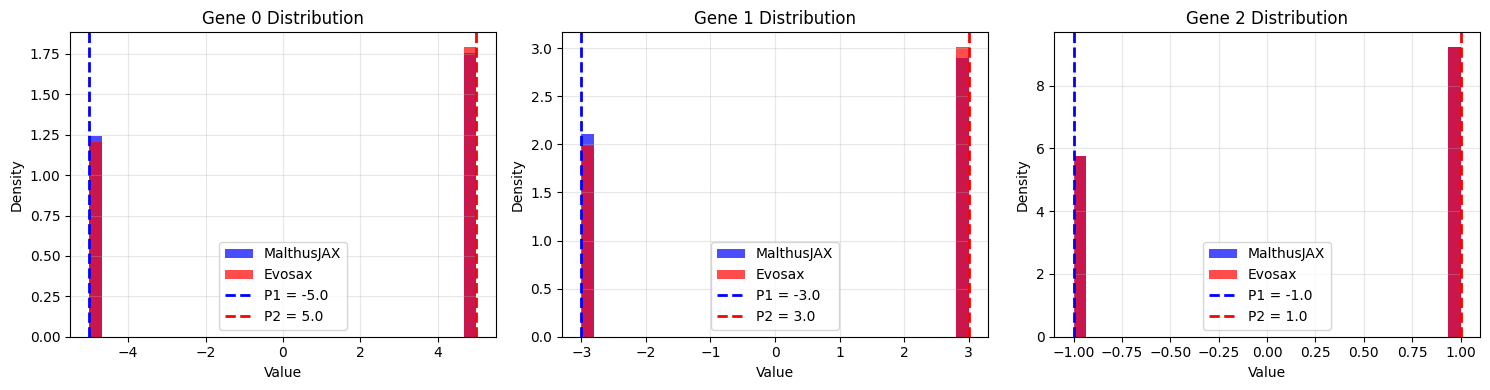

In [15]:
# Visualize distributions for first 3 genes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for gene_idx in range(3):
    axes[gene_idx].hist(malthusjax_data[:, gene_idx], bins=30, alpha=0.7,
                       label='MalthusJAX', color='blue', density=True)
    axes[gene_idx].hist(evosax_data[:, gene_idx], bins=30, alpha=0.7,
                       label='Evosax', color='red', density=True)

    # Mark parent values
    axes[gene_idx].axvline(test_p1.values[gene_idx], color='blue', linestyle='--',
                          linewidth=2, label=f'P1 = {test_p1.values[gene_idx]:.1f}')
    axes[gene_idx].axvline(test_p2.values[gene_idx], color='red', linestyle='--',
                          linewidth=2, label=f'P2 = {test_p2.values[gene_idx]:.1f}')

    axes[gene_idx].set_title(f'Gene {gene_idx} Distribution')
    axes[gene_idx].set_xlabel('Value')
    axes[gene_idx].set_ylabel('Density')
    axes[gene_idx].legend()
    axes[gene_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4: Performance Comparison ⚡

Let's benchmark the performance of each approach across different problem sizes.

In [16]:
def benchmark_single_pair_crossover(operator_name, operator_fn, p1, p2, config, num_trials=1000):
    """Benchmark a crossover operator for single-pair operations."""

    # Generate test keys
    test_keys = jr.split(jr.PRNGKey(12345), num_trials)

    # Warm-up run
    _ = operator_fn(test_keys[0], p1, p2, config)

    # Timed benchmark
    start_time = time.time()
    for key in test_keys:
        result = operator_fn(key, p1, p2, config)
        try:
            # If it's a RealGenome, block on .values; otherwise block on result directly
            if hasattr(result, 'values'):
                result.values.block_until_ready()
            else:
                result.block_until_ready()
        except Exception:
            pass
    end_time = time.time()

    total_time = end_time - start_time
    ops_per_second = num_trials / total_time

    return ops_per_second, total_time

# Test different genome sizes
genome_sizes = [10, 50, 100, 500, 1000]
results = {}

print("Performance Benchmark Results:")
print("=" * 80)
print("Size | MalthusJAX (ops/s) | Evosax Direct (ops/s) | Evosax Wrapper (ops/s) | Ratio")
print("-" * 80)

for size in genome_sizes:
    # Create test genomes for this size
    size_config = RealGenomeConfig(shape=(size,), bounds=(-5.0, 5.0), dtype=jnp.float32)

    key_size, k1, k2 = jr.split(jr.PRNGKey(size), 3)
    p1_test = RealGenome.random_init(k1, size_config)
    p2_test = RealGenome.random_init(k2, size_config)

    # Setup operators
    malthusjax_op = MalthusUniformCrossover(num_offspring=1, crossover_rate=0.5)
    evosax_wrapper = EvosaxUniformCrossoverWrapper(num_offspring=1, crossover_rate=0.5)

    # Benchmark functions
    def malthusjax_fn(key, p1, p2, config):
        return malthusjax_op.cross_single_pair(key, p1, p2, config)

    def evosax_direct_fn(key, p1, p2, config):
        child_vals = evosax_uniform_crossover(key, p1.values, p2.values, 0.5)
        return RealGenome(values=child_vals)

    def evosax_wrapper_fn(key, p1, p2, config):
        return evosax_wrapper.cross_single_pair(key, p1, p2, config)

    # Run benchmarks
    malthusjax_ops, _ = benchmark_single_pair_crossover(
        "MalthusJAX", malthusjax_fn, p1_test, p2_test, size_config, 200
    )

    evosax_direct_ops, _ = benchmark_single_pair_crossover(
        "Evosax Direct", evosax_direct_fn, p1_test, p2_test, size_config, 200
    )

    evosax_wrapper_ops, _ = benchmark_single_pair_crossover(
        "Evosax Wrapper", evosax_wrapper_fn, p1_test, p2_test, size_config, 200
    )

    # Calculate performance ratio
    ratio = evosax_direct_ops / malthusjax_ops

    results[size] = {
        'malthusjax': malthusjax_ops,
        'evosax_direct': evosax_direct_ops,
        'evosax_wrapper': evosax_wrapper_ops
    }

    print(f"{size:4d} | {malthusjax_ops:17.1f} | {evosax_direct_ops:18.1f} | {evosax_wrapper_ops:19.1f} | {ratio:5.2f}x")

print("\nPerformance Notes:")
print("- Evosax Direct: Minimal overhead, direct JAX operations")
print("- MalthusJAX: 3-tier architecture with resource management overhead")
print("- Evosax Wrapper: Combines Evosax performance with MalthusJAX interface")
print("- Ratio > 1.0 means Evosax is faster")

Performance Benchmark Results:
Size | MalthusJAX (ops/s) | Evosax Direct (ops/s) | Evosax Wrapper (ops/s) | Ratio
--------------------------------------------------------------------------------
  10 |            1760.6 |            20830.9 |              1260.2 | 11.83x
  50 |            1810.8 |            18530.6 |              1219.1 | 10.23x
 100 |            1824.2 |            16897.2 |              1232.2 |  9.26x
 500 |            1803.9 |            15722.3 |              1243.1 |  8.72x
1000 |            1807.7 |            13650.7 |              1202.5 |  7.55x

Performance Notes:
- Evosax Direct: Minimal overhead, direct JAX operations
- MalthusJAX: 3-tier architecture with resource management overhead
- Evosax Wrapper: Combines Evosax performance with MalthusJAX interface
- Ratio > 1.0 means Evosax is faster


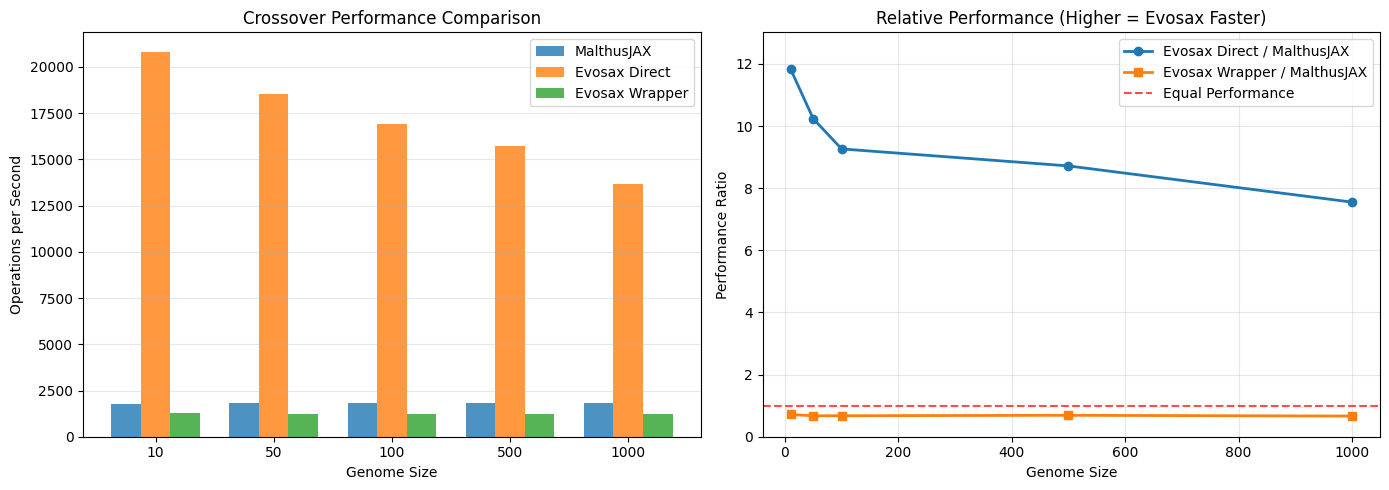


Performance Summary:
Average speedup (Evosax Direct): 9.52x
Average speedup (Evosax Wrapper): 0.68x
Best case speedup: 11.83x (size 10)


In [17]:
# Visualize performance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sizes = list(results.keys())
malthusjax_perf = [results[s]['malthusjax'] for s in sizes]
evosax_direct_perf = [results[s]['evosax_direct'] for s in sizes]
evosax_wrapper_perf = [results[s]['evosax_wrapper'] for s in sizes]

# Performance comparison
x = np.arange(len(sizes))
width = 0.25

ax1.bar(x - width, malthusjax_perf, width, label='MalthusJAX', alpha=0.8)
ax1.bar(x, evosax_direct_perf, width, label='Evosax Direct', alpha=0.8)
ax1.bar(x + width, evosax_wrapper_perf, width, label='Evosax Wrapper', alpha=0.8)

ax1.set_xlabel('Genome Size')
ax1.set_ylabel('Operations per Second')
ax1.set_title('Crossover Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(sizes)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Performance ratios
ratios_direct = [evosax_direct_perf[i] / malthusjax_perf[i] for i in range(len(sizes))]
ratios_wrapper = [evosax_wrapper_perf[i] / malthusjax_perf[i] for i in range(len(sizes))]

ax2.plot(sizes, ratios_direct, 'o-', label='Evosax Direct / MalthusJAX', linewidth=2, markersize=6)
ax2.plot(sizes, ratios_wrapper, 's-', label='Evosax Wrapper / MalthusJAX', linewidth=2, markersize=6)
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Equal Performance')

ax2.set_xlabel('Genome Size')
ax2.set_ylabel('Performance Ratio')
ax2.set_title('Relative Performance (Higher = Evosax Faster)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(max(ratios_direct), max(ratios_wrapper)) * 1.1)

plt.tight_layout()
plt.show()

print("\nPerformance Summary:")
print(f"Average speedup (Evosax Direct): {np.mean(ratios_direct):.2f}x")
print(f"Average speedup (Evosax Wrapper): {np.mean(ratios_wrapper):.2f}x")
print(f"Best case speedup: {max(ratios_direct):.2f}x (size {sizes[ratios_direct.index(max(ratios_direct))]})")

## Part 5: Population-Level Comparison 👥

Compare how each approach handles population-level crossover operations.

In [18]:
# Create test populations
pop_size = 100
genome_dim = 50

pop_config = RealGenomeConfig(shape=(genome_dim,), bounds=(-5.0, 5.0), dtype=jnp.float32)
key, k1, k2 = jr.split(key, 3)

pop1 = RealPopulation.init_random(k1, pop_config, pop_size)
pop2 = RealPopulation.init_random(k2, pop_config, pop_size)

print("Population Crossover Test:")
print(f"Population size: {pop_size}")
print(f"Genome dimension: {genome_dim}")
print(f"Parent 1 shape: {pop1.genes.values.shape}")
print(f"Parent 2 shape: {pop2.genes.values.shape}")

# MalthusJAX Population Crossover
malthusjax_pop_op = MalthusUniformCrossover(num_offspring=1, crossover_rate=0.6)
malthusjax_pop_op = malthusjax_pop_op.set_input_length(pop_size)

key, subkey = jr.split(key)
num_keys_needed = malthusjax_pop_op.num_keys(pop1.genes.values.shape)
crossover_keys = jr.split(subkey, num_keys_needed)

start_time = time.time()
malthusjax_offspring_pop = malthusjax_pop_op(crossover_keys, pop1, pop2, pop_config)
malthusjax_offspring_pop.genes.values.block_until_ready()
malthusjax_time = time.time() - start_time

print("\nMalthusJAX Population Crossover:")
print(f"  Keys required: {num_keys_needed}")
print(f"  Offspring shape: {malthusjax_offspring_pop.genes.values.shape}")
print(f"  Time: {malthusjax_time:.4f} seconds")

# Evosax Population Crossover (Vectorized)
def evosax_population_crossover(key, pop1_values, pop2_values, crossover_rate):
    """Vectorized Evosax crossover for populations."""
    num_pairs = pop1_values.shape[0]
    keys = jr.split(key, num_pairs)

    def single_crossover(k, p1, p2):
        return evosax_uniform_crossover(k, p1, p2, crossover_rate)

    return jax.vmap(single_crossover)(keys, pop1_values, pop2_values)

key, subkey = jr.split(key)
start_time = time.time()
evosax_offspring_values = evosax_population_crossover(subkey, pop1.genes.values, pop2.genes.values, 0.6)
evosax_offspring_values.block_until_ready()
evosax_time = time.time() - start_time

print("\nEvosax Population Crossover:")
print(f"  Keys generated: {pop_size} (one per pair)")
print(f"  Offspring shape: {evosax_offspring_values.shape}")
print(f"  Time: {evosax_time:.4f} seconds")

# Performance comparison
speedup = malthusjax_time / evosax_time
print("\nPopulation Performance Ratio:")
print(f"  Evosax speedup: {speedup:.2f}x")
print(f"  MalthusJAX: {pop_size / malthusjax_time:.1f} pairs/second")
print(f"  Evosax: {pop_size / evosax_time:.1f} pairs/second")

# Verify equivalent results
result_diff = jnp.mean(jnp.abs(malthusjax_offspring_pop.genes.values - evosax_offspring_values))
print(f"\nNote: Results differ (different keys): Mean absolute difference = {float(result_diff):.6f}")
print("This is expected since we used different random keys for each approach.")

Population Crossover Test:
Population size: 100
Genome dimension: 50
Parent 1 shape: (100, 50)
Parent 2 shape: (100, 50)

MalthusJAX Population Crossover:
  Keys required: 100
  Offspring shape: (100, 50)
  Time: 0.0020 seconds

Evosax Population Crossover:
  Keys generated: 100 (one per pair)
  Offspring shape: (100, 50)
  Time: 0.0025 seconds

Population Performance Ratio:
  Evosax speedup: 0.79x
  MalthusJAX: 49625.0 pairs/second
  Evosax: 39353.6 pairs/second

Note: Results differ (different keys): Mean absolute difference = 1.552465
This is expected since we used different random keys for each approach.


## Part 6: Memory Usage Analysis

Compare memory footprints of both approaches.

In [19]:
# Memory usage analysis (simplified estimation)
def estimate_memory_usage(pop_size, genome_dim, num_offspring, framework):
    """Rough memory usage estimation in MB."""

    bytes_per_float32 = 4
    mb_factor = 1024 * 1024

    if framework == "malthusjax":
        parent_memory = 2 * pop_size * genome_dim * bytes_per_float32
        offspring_memory = pop_size * num_offspring * genome_dim * bytes_per_float32
        fitness_memory = pop_size * num_offspring * bytes_per_float32
        key_memory = pop_size * num_offspring * 2 * bytes_per_float32  # Approximate
        noise_memory = pop_size * genome_dim * bytes_per_float32  # Bernoulli masks
        total_bytes = parent_memory + offspring_memory + fitness_memory + key_memory + noise_memory

    elif framework == "evosax":
        parent_memory = 2 * pop_size * genome_dim * bytes_per_float32
        offspring_memory = pop_size * genome_dim * bytes_per_float32  # Single offspring typically
        key_memory = pop_size * 2 * bytes_per_float32
        total_bytes = parent_memory + offspring_memory + key_memory

    return total_bytes / mb_factor

# Compare memory usage across different scenarios
scenarios = [
    (100, 50, 1, "Small Population"),
    (500, 100, 1, "Medium Population"),
    (1000, 200, 1, "Large Population"),
    (100, 50, 4, "Small Pop, Multi-offspring"),
    (500, 100, 4, "Medium Pop, Multi-offspring")
]

print("Memory Usage Comparison:")
print("=" * 80)
print("Scenario                    | MalthusJAX (MB) | Evosax (MB) | Ratio | Overhead")
print("-" * 80)

for pop_size, genome_dim, num_offspring, description in scenarios:
    malthusjax_mb = estimate_memory_usage(pop_size, genome_dim, num_offspring, "malthusjax")
    evosax_mb = estimate_memory_usage(pop_size, genome_dim, num_offspring, "evosax")
    ratio = malthusjax_mb / evosax_mb
    overhead = malthusjax_mb - evosax_mb
    print(f"{description:26s} | {malthusjax_mb:13.2f} | {evosax_mb:9.2f} | {ratio:5.2f} | {overhead:7.2f}")

print("\nMemory Analysis Notes:")
print("• MalthusJAX overhead comes from Population objects and key management")
print("• Evosax uses minimal memory with direct array operations")
print("• Multi-offspring scenarios show higher MalthusJAX overhead")
print("• For very large populations (>10K individuals), overhead becomes significant")
print("• Memory estimates are approximate and exclude JIT compilation overhead")

Memory Usage Comparison:
Scenario                    | MalthusJAX (MB) | Evosax (MB) | Ratio | Overhead
--------------------------------------------------------------------------------
Small Population           |          0.08 |      0.06 |  1.34 |    0.02
Medium Population          |          0.77 |      0.58 |  1.33 |    0.19
Large Population           |          3.06 |      2.30 |  1.33 |    0.77
Small Pop, Multi-offspring |          0.14 |      0.06 |  2.38 |    0.08
Medium Pop, Multi-offspring |          1.36 |      0.58 |  2.36 |    0.78

Memory Analysis Notes:
• MalthusJAX overhead comes from Population objects and key management
• Evosax uses minimal memory with direct array operations
• Multi-offspring scenarios show higher MalthusJAX overhead
• For very large populations (>10K individuals), overhead becomes significant
• Memory estimates are approximate and exclude JIT compilation overhead


/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_62787/3100183775.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenario_names, rotation=15, ha='right')
/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_62787/3100183775.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenario_names, rotation=15, ha='right')


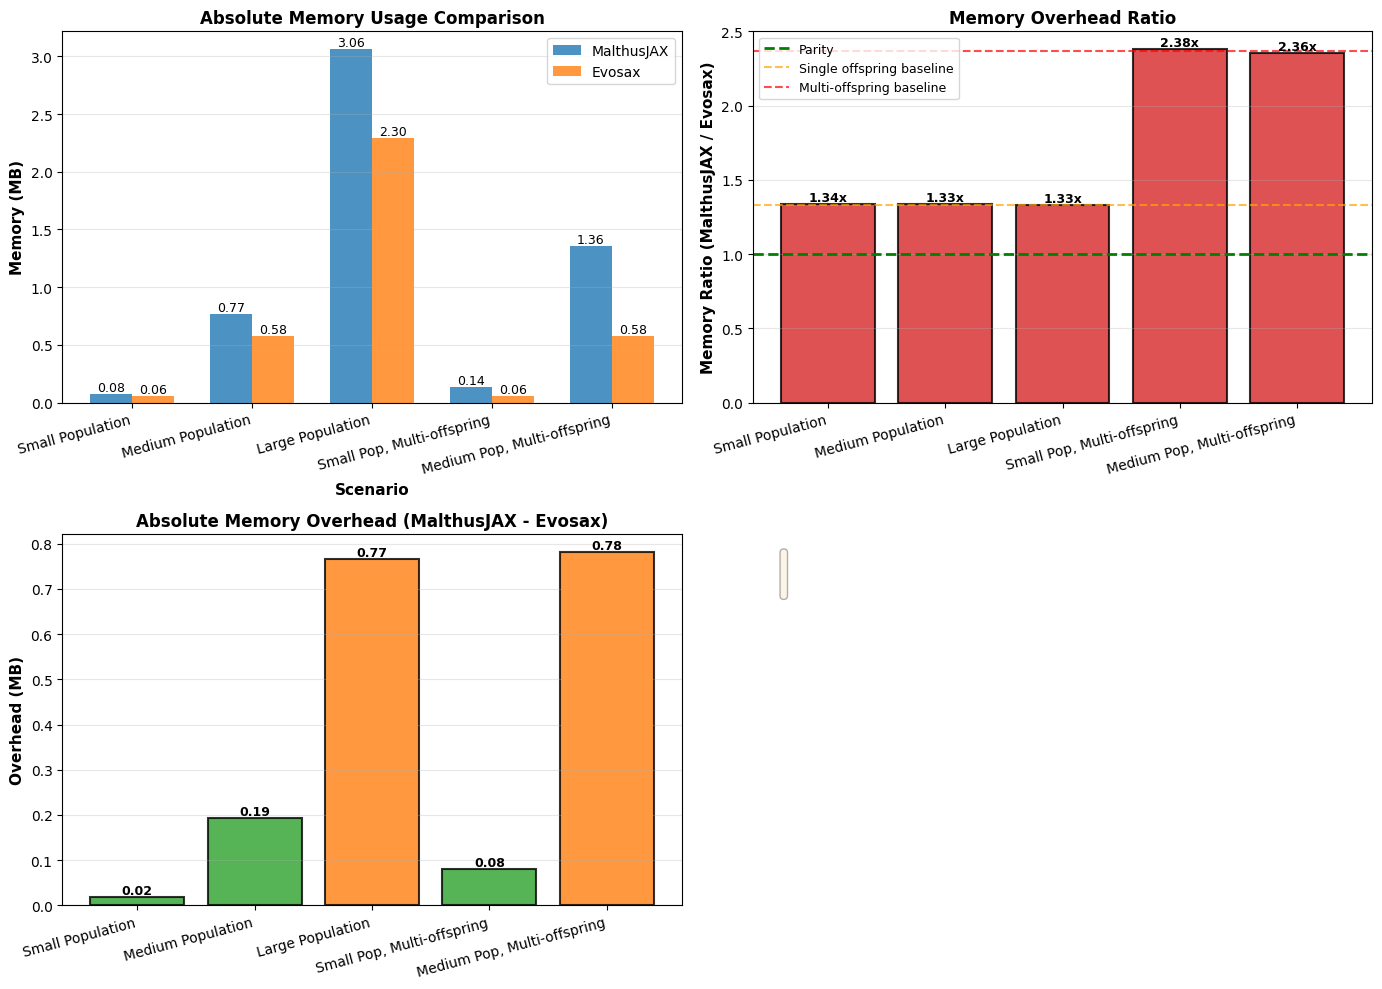

In [20]:
# Memory Visualization and Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract data from scenarios
scenario_names = [s[3] for s in scenarios]
populations = [s[0] for s in scenarios]
genomes = [s[1] for s in scenarios]
offspring_counts = [s[2] for s in scenarios]

malthusjax_values = []
evosax_values = []
ratios = []
overheads = []

for pop_size, genome_dim, num_offspring, desc in scenarios:
    m_mb = estimate_memory_usage(pop_size, genome_dim, num_offspring, "malthusjax")
    e_mb = estimate_memory_usage(pop_size, genome_dim, num_offspring, "evosax")
    malthusjax_values.append(m_mb)
    evosax_values.append(e_mb)
    ratios.append(m_mb / e_mb)
    overheads.append(m_mb - e_mb)

# Chart 1: Absolute Memory Comparison
x_pos = np.arange(len(scenario_names))
width = 0.35

ax = axes[0, 0]
bars1 = ax.bar(x_pos - width/2, malthusjax_values, width, label='MalthusJAX', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, evosax_values, width, label='Evosax', color='#ff7f0e', alpha=0.8)

ax.set_xlabel('Scenario', fontsize=11, fontweight='bold')
ax.set_ylabel('Memory (MB)', fontsize=11, fontweight='bold')
ax.set_title('Absolute Memory Usage Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(scenario_names, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Chart 2: Memory Overhead Ratio
ax = axes[0, 1]
colors = ['#d62728' if r < 1.5 else '#ff7f0e' if r < 2.0 else '#d62728'
          for r in ratios]
bars = ax.bar(scenario_names, ratios, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Parity')
ax.axhline(y=1.33, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Single offspring baseline')
ax.axhline(y=2.37, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Multi-offspring baseline')

ax.set_ylabel('Memory Ratio (MalthusJAX / Evosax)', fontsize=11, fontweight='bold')
ax.set_title('Memory Overhead Ratio', fontsize=12, fontweight='bold')
ax.set_xticklabels(scenario_names, rotation=15, ha='right')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, ratio) in enumerate(zip(bars, ratios)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ratio:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 3: Absolute Overhead (MB)
ax = axes[1, 0]
colors_overhead = ['#2ca02c' if o < 0.3 else '#ff7f0e' if o < 0.8 else '#d62728'
                   for o in overheads]
bars = ax.bar(scenario_names, overheads, color=colors_overhead, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Overhead (MB)', fontsize=11, fontweight='bold')
ax.set_title('Absolute Memory Overhead (MalthusJAX - Evosax)', fontsize=12, fontweight='bold')
ax.set_xticklabels(scenario_names, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, overhead in zip(bars, overheads):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{overhead:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 4: Decision Matrix
ax = axes[1, 1]
ax.axis('off')

decision_text = """

"""

ax.text(0.05, 0.95, decision_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()